core           INFO 	Loading data for British Grand Prix - Race [v3.8.3]
req            INFO 	No cached data found for session_info. Loading data...
_api           INFO 	Fetching session info data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for lap_count. Loading data...
_api           INFO 	Fetching lap count data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for track_status_data. Loading data...
_api           INFO 	Fetching track status data...
req            INFO 	Data has been written to cache!
req            INFO 	No ca

Data ingested successfully. DataFrame shape: (682, 18)


,Date,SessionTime,DriverAhead,DistanceToDriverAhead,Time,RPM,Speed,nGear,Throttle,Brake,DRS,Source,Distance,RelativeDistance,Status,X,Y,Z
2,2024-07-07 15:18:14.967,0 days 02:13:17.938000,,66.808333,0 days 00:00:00,11515.525000,255.625000,6,100.0,False,0,interpolation,0.052679,0.000009,OnTrack,-1746.572603,1222.620354,1963.152228
3,2024-07-07 15:18:15.072,0 days 02:13:18.043000,,66.808333,0 days 00:00:00.105000,11657.931163,258.906248,6,100.0,False,0,pos,7.624745,0.001314,OnTrack,-1701.000000,1283.000000,1964.000000
4,2024-07-07 15:18:15.075,0 days 02:13:18.046000,,66.808333,0 days 00:00:00.108000,11662.000000,259.000000,6,100.0,False,0,car,7.842222,0.001351,OnTrack,-1699.682956,1284.726135,1964.018621
5,2024-07-07 15:18:15.352,0 days 02:13:18.323000,,66.808333,0 days 00:00:00.385000,10864.949619,263.629528,6,100.0,False,0,pos,28.177308,0.004856,OnTrack,-1575.000000,1444.000000,1965.000000
6,2024-07-07 15:18:15.434,0 days 02:13:18.405000,4,66.808333,0 days 00:00:00.467000,10629.000000,265.000000,6,100.0,False,0,car,34.268611,0.005905,OnTrack,-1537.339638,1490.830998,1965.516355


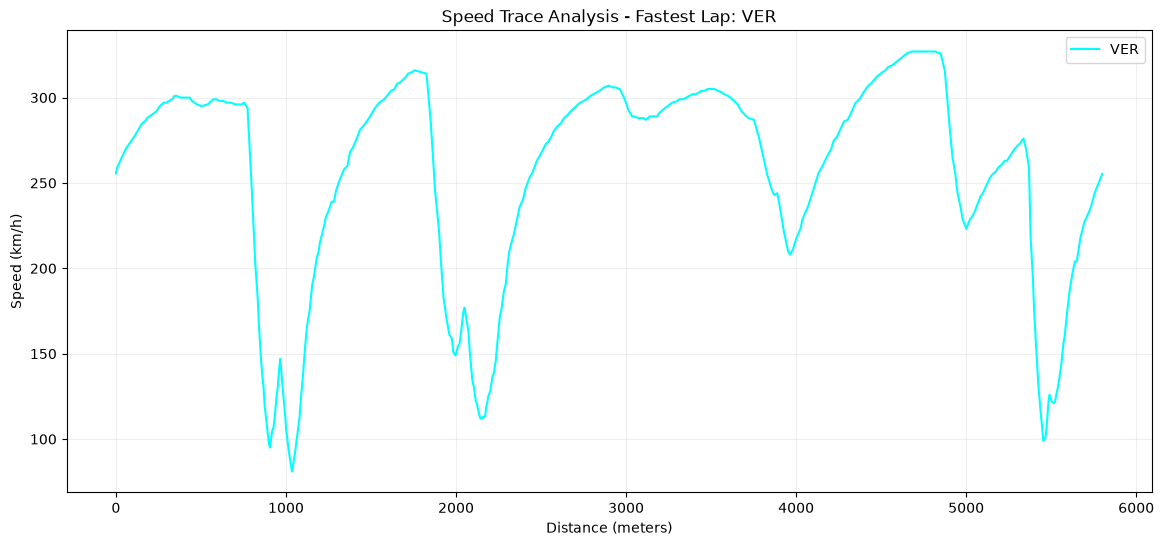

In [ ]:
"""
Module: Exploratory Data Analysis (EDA) - F1 Telemetry
Description: Retrieves and processes initial telemetry data utilizing the FastF1 API
             to validate data structures, establish caching protocols, and extract 
             baseline lap time physical channels.
"""

import os
import fastf1
import fastf1.plotting
import matplotlib.pyplot as plt
import pandas as pd

# Define the absolute path for the cache directory to ensure stability across executions
CACHE_DIR = os.path.abspath("../data/cache/")
if not os.path.exists(CACHE_DIR):
    os.makedirs(CACHE_DIR)

# Enable cache to mitigate redundant API calls and reduce network latency during EDA
fastf1.Cache.enable_cache(CACHE_DIR)

def fetch_fastest_lap_telemetry(year: int, grand_prix: str, session_type: str, driver_id: str) -> pd.DataFrame:
    """
    Retrieves and isolates the physical channel telemetry for a specific driver's fastest lap.

    Args:
        year (int): Championship year.
        grand_prix (str): Name or location of the event (e.g., 'Silverstone', 'Monza').
        session_type (str): Type of session ('FP1', 'FP2', 'FP3', 'Q', 'S', 'R').
        driver_id (str): Three-letter driver identifier (e.g., 'VER', 'HAM', 'LEC').

    Returns:
        pd.DataFrame: DataFrame containing high-frequency telemetry channels 
                      (Speed, RPM, nGear, Throttle, Brake, X, Y, Z).
    """
    session = fastf1.get_session(year, grand_prix, session_type)
    
    # Load session data; telemetry is requested automatically
    session.load(weather=False, messages=False)
    
    # Isolate the fastest lap object for the specified driver to normalize performance metrics
    fastest_lap = session.laps.pick_drivers([driver_id]).pick_fastest()
    
    # Extract telemetry slice
    telemetry = fastest_lap.get_telemetry()
    
    return telemetry

def plot_speed_trace(telemetry: pd.DataFrame, driver_id: str):
    """
    Generates a speed trace visualization mapping vehicle velocity against track distance.
    Leverages FastF1's plotting context for standardized color schemes.
    """
    # Initialize FastF1 matplotlib context for default dark theme and team colors
    fastf1.plotting.setup_mpl()
    
    fig, ax = plt.subplots(figsize=(14, 6))
    
    # Plotting Speed over Distance
    ax.plot(telemetry['Distance'], telemetry['Speed'], label=driver_id, color='cyan')
    
    ax.set_xlabel('Distance (meters)')
    ax.set_ylabel('Speed (km/h)')
    ax.set_title(f'Speed Trace Analysis - Fastest Lap: {driver_id}')
    ax.legend()
    ax.grid(alpha=0.2)
    
    plt.show()

if __name__ == "__main__":
    # Execution block for initial baseline testing
    TARGET_YEAR = 2024
    TARGET_GP = 'Silverstone'
    SESSION = 'R'
    DRIVER = 'VER'
    
    try:
        df_telemetry = fetch_fastest_lap_telemetry(TARGET_YEAR, TARGET_GP, SESSION, DRIVER)
        print(f"Data ingested successfully. DataFrame shape: {df_telemetry.shape}")
        
        # Display the first 5 rows to inspect data structure and sensor channels
        display(df_telemetry.head())
        
        plot_speed_trace(df_telemetry, DRIVER)
        
    except Exception as e:
        print(f"Pipeline execution failed: {e}")

In [ ]:
"""
Module: Telemetry Comparison Analysis
Description: Extracts and synchronizes high-frequency telemetry channels (Speed, Throttle, Brake) 
             for two distinct drivers to perform a micro-sector performance comparison.
"""

import fastf1
import fastf1.plotting
import matplotlib.pyplot as plt

def plot_head_to_head_telemetry(year: int, grand_prix: str, session_type: str, driver1: str, driver2: str):
    """
    Generates a synchronized multi-plot figure comparing speed, throttle application, 
    and braking points between two drivers during their fastest laps.

    Args:
        year (int): Championship year.
        grand_prix (str): Event location/name.
        session_type (str): Session identifier.
        driver1 (str): Three-letter identifier for the primary driver.
        driver2 (str): Three-letter identifier for the secondary driver.
    """
    # Load session and enable fastf1 color mappings
    session = fastf1.get_session(year, grand_prix, session_type)
    session.load(weather=False, messages=False)
    fastf1.plotting.setup_mpl()

    # Isolate fastest laps for both drivers
    lap_d1 = session.laps.pick_drivers([driver1]).pick_fastest()
    lap_d2 = session.laps.pick_drivers([driver2]).pick_fastest()

    # Extract telemetry arrays
    tel_d1 = lap_d1.get_telemetry()
    tel_d2 = lap_d2.get_telemetry()

    # Extract team colors dynamically from the lap object to avoid versioning attribute errors
    color_d1 = fastf1.plotting.team_color(lap_d1['Team'])
    color_d2 = fastf1.plotting.team_color(lap_d2['Team'])

    # Initialize a multi-panel figure sharing the X-axis (Distance)
    fig, axes = plt.subplots(3, 1, figsize=(15, 12), sharex=True)
    fig.suptitle(f"Telemetry Comparison: {driver1} vs {driver2} - {grand_prix} {year}", fontsize=16)

    # Subplot 1: Speed (km/h)
    axes[0].plot(tel_d1['Distance'], tel_d1['Speed'], label=driver1, color=color_d1)
    axes[0].plot(tel_d2['Distance'], tel_d2['Speed'], label=driver2, color=color_d2)
    axes[0].set_ylabel("Speed (km/h)")
    axes[0].legend(loc="lower right")
    axes[0].grid(alpha=0.2)

    # Subplot 2: Throttle (%)
    axes[1].plot(tel_d1['Distance'], tel_d1['Throttle'], label=driver1, color=color_d1)
    axes[1].plot(tel_d2['Distance'], tel_d2['Throttle'], label=driver2, color=color_d2)
    axes[1].set_ylabel("Throttle (%)")
    axes[1].grid(alpha=0.2)

    # Subplot 3: Brake (On/Off boolean converted to integer for plotting)
    axes[2].plot(tel_d1['Distance'], tel_d1['Brake'].astype(int), label=driver1, color=color_d1)
    axes[2].plot(tel_d2['Distance'], tel_d2['Brake'].astype(int), label=driver2, color=color_d2)
    axes[2].set_ylabel("Brake (On/Off)")
    axes[2].set_xlabel("Distance (meters)")
    axes[2].set_yticks([0, 1])
    axes[2].set_yticklabels(['Off', 'On'])
    axes[2].grid(alpha=0.2)

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    # Execute the comparison module for Silverstone 2024
    plot_head_to_head_telemetry(2024, 'Silverstone', 'R', 'VER', 'NOR')

core           INFO 	Loading data for British Grand Prix - Race [v3.8.3]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data


req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
core        WARNING 	Failed to perform lap accuracy check - all laps marked as inaccurate (driver 10)
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
core           INFO 	Finished loading data for 20 drivers: ['44', '1', '4', '81', '55', '27', '18', '14', '23', '22', '2', '20', '3', '16', '77', '31', '11', '24', '63', '10']


AttributeError: module 'fastf1.plotting' has no attribute 'driver_color'